# Tasks and Deliverables for this notebook.

(!) The endpoint I'm interested in: https://api.rescuegroups.org/v5/public/animals/search/cats/

(?) How to navigate the max limit?
    
1) Pick two independent variables to analyze in the rescue_groups_animals.csv.
2) Clean and explore the dataset using describe and info functions.
3) Create the dependent variable column - length of stay.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [47]:
# inspect the cleaned data
df = pd.read_csv('../data/clean/clean_cats_data.csv')
df.head()


,Unnamed: 0,id,sex,sizeCurrent,sizeGroup,ageGroup,ageString,breedString,colorDetails,vocalLevel,...,isKidsOk,adultSexesOk,obedienceTraining,ownerExperience,newPeopleReaction,pictureCount,videoCount,adoptedDate,availableDate,length_of_stay
0,2,10000193,Male,14.0,Large,Adult,8 Years 8 Months,Domestic Short Hair / Mixed,NaN,NaN,...,True,NaN,NaN,NaN,NaN,5,0,2016-08-13 00:00:00+00:00,2016-05-17 00:00:00+00:00,88.0
1,9,10000236,Female,NaN,NaN,Adult,10 Years 6 Months,Domestic Short Hair (short coat),NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,4,0,2016-06-25 00:00:00+00:00,2016-05-14 00:00:00+00:00,42.0
2,10,10000242,Female,NaN,NaN,Baby,6 Years 8 Months,Domestic Short Hair (short coat),White w/calico,NaN,...,NaN,NaN,NaN,NaN,NaN,2,0,2016-05-28 00:00:00+00:00,2016-05-14 00:00:00+00:00,14.0
3,11,10000252,Female,NaN,NaN,Baby,6 Years 8 Months,Domestic Short Hair (short coat),Tabby w/white,NaN,...,NaN,NaN,NaN,NaN,NaN,2,0,2016-05-28 00:00:00+00:00,2016-05-14 00:00:00+00:00,14.0
4,20,10000959,Male,NaN,Medium,Adult,NaN,Domestic Short Hair (short coat),NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1,0,2016-06-11 00:00:00+00:00,2016-05-13 00:00:00+00:00,29.0


In [48]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4528 entries, 0 to 4527
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             4528 non-null   int64  
 1   id                     4528 non-null   int64  
 2   sex                    4496 non-null   str    
 3   sizeCurrent            1684 non-null   float64
 4   sizeGroup              2942 non-null   str    
 5   ageGroup               4138 non-null   str    
 6   ageString              4196 non-null   str    
 7   breedString            4528 non-null   str    
 8   colorDetails           1304 non-null   str    
 9   vocalLevel             605 non-null    str    
 10  sheddingLevel          808 non-null    str    
 11  energyLevel            1413 non-null   str    
 12  exerciseNeeds          1098 non-null   str    
 13  isSpecialNeeds         3388 non-null   object 
 14  isCurrentVaccinations  2995 non-null   object 
 15  isDeclawed     

A few columns such as vocalLevel, sheddingLevel and obedienceTraining have exceptionally high missing values. Available data can still be evaluated and compared against the length of stay to pick up on the effect of those fields on pet desirability.

In [23]:
df.describe()

,Unnamed: 0,id,sizeCurrent,pictureCount,videoCount,length_of_stay
count,4528.000000,4.528000e+03,1684.000000,4528.000000,4528.000000,4528.000000
mean,25929.707597,1.021343e+07,4.757167,2.707155,0.038428,73.509276
std,14454.727046,1.639972e+06,3.293079,2.312158,0.239336,196.663582
min,2.000000,1.067000e+04,0.500000,0.000000,0.000000,0.000000
25%,13871.750000,1.022049e+07,2.500000,1.000000,0.000000,9.000000
50%,26048.500000,1.050011e+07,3.310000,2.000000,0.000000,25.000000
75%,38723.750000,1.073869e+07,6.112500,4.000000,0.000000,63.000000
max,49973.000000,1.095925e+07,28.000000,23.000000,4.000000,3481.000000


Length of stay ranges anywhere from 0 days to 3481 days. The middle 50% of cats took 9-63 days as of being available to get adopted, with the median being 25 days, or about a month.

(array([3.954e+03, 3.180e+02, 9.500e+01, 5.300e+01, 2.000e+01, 1.700e+01,
        9.000e+00, 9.000e+00, 9.000e+00, 1.100e+01, 3.000e+00, 2.000e+00,
        6.000e+00, 7.000e+00, 4.000e+00, 1.000e+00, 2.000e+00, 1.000e+00,
        1.000e+00, 0.000e+00, 2.000e+00, 0.000e+00, 0.000e+00, 1.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 2.000e+00, 1.000e+00]),
 array([   0.        ,  116.03333333,  232.06666667,  348.1       ,
         464.13333333,  580.16666667,  696.2       ,  812.23333333,
         928.26666667, 1044.3       , 1160.33333333, 1276.36666667,
        1392.4       , 1508.43333333, 1624.46666667, 1740.5       ,
        1856.53333333, 1972.56666667, 2088.6       , 2204.63333333,
        2320.66666667, 2436.7       , 2552.73333333, 2668.76666667,
        2784.8       , 2900.83333333, 3016.86666667, 3132.9       ,
        3248.93333333, 3364.96666667, 3481.        ]),
 <BarContainer object of 30 artists>)

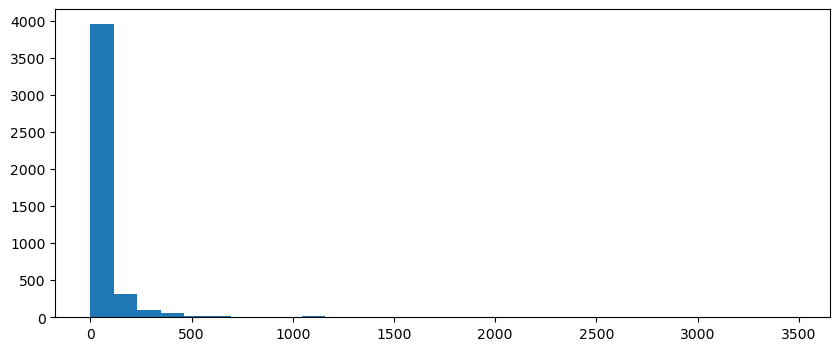

In [43]:
plt.figure(figsize=(10, 4))
plt.hist(df['length_of_stay'], bins=30)


Length of stay as of being posted is right-skewed, with most cats being adopted in less than 250 days, and nearly all under 500.

In [45]:
df['breedString'].describe()

count                                 4528
unique                                 406
top       Domestic Short Hair (short coat)
freq                                  1064
Name: breedString, dtype: object

~23% of cat breeds that are in the dataset and completed adoption are of the domestic short hair, short coat breed, out of the 406 unique breeds identified.

In [59]:
pivot = df['breedString'].value_counts()
pivot.head(10)

breedString
Domestic Short Hair (short coat)                    1064
Domestic Short Hair / Mixed (short coat)             532
Domestic Short Hair / Mixed                          492
Domestic Short Hair                                  271
Domestic Medium Hair (medium coat)                   200
Domestic Short Hair / Tabby / Mixed (short coat)     137
Domestic Long Hair (long coat)                        78
Domestic Medium Hair / Mixed                          69
Domestic Short Hair / Tabby (short coat)              66
Domestic Medium Hair / Mixed (medium coat)            56
Name: count, dtype: int64

The naming convention for breeds of cat here are unclear. If this was important for further analysis, I would reference any existing pictures attached to the animal postings for better understanding.

We do see a trend of the top 4 most common breed of cat in our data being short haired cats (2359/4528)(~52%), as opposed to those with long or medium length hair.

In [ ]:
df['sheddingLevel'].describe()

count          808
unique           2
top       Moderate
freq           801
Name: sheddingLevel, dtype: object

In [66]:
pivot = df['sheddingLevel'].value_counts()
pivot.head()

sheddingLevel
Moderate    801
High          7
Name: count, dtype: int64

There is less variety in shedding levels to analyze than I thought, almost all animals having been labeled as shedding a moderate amount.

In [67]:
df['sizeGroup'].describe()

count       2942
unique         4
top       Medium
freq        1670
Name: sizeGroup, dtype: object

In [68]:
pivot = df['sizeGroup'].value_counts()
pivot.head()

sizeGroup
Medium     1670
Small      1097
Large       165
X-Large      10
Name: count, dtype: int64

Majority of cats are small or medium, nearly half of the total categorized belonging to either group. 